<a href="https://colab.research.google.com/github/parika8ec-hub/AI_Assignment14/blob/main/Assignment14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dataset Preparation:

In [32]:
#Install library
!pip install fairlearn
!pip install lime

In [33]:
#Import libraries
from sklearn.datasets import fetch_openml
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from fairlearn.metrics import MetricFrame, selection_rate, false_positive_rate, true_positive_rate
import matplotlib.pyplot as plt
import shap
from lime.lime_tabular import LimeTabularExplainer

In [34]:
#Load Adult Income dataset from OpenML
data = fetch_openml(name='adult', version=2, as_frame=True)

# Convert the dataset into a pandas DataFrame
Adult_Income_data = data.frame

#Display the few rows of dataset
print('Few rows of Adult Income dataset:',Adult_Income_data.head())

Few rows of Adult Income dataset:    age  workclass  fnlwgt     education  education-num      marital-status  \
0   25    Private  226802          11th              7       Never-married   
1   38    Private   89814       HS-grad              9  Married-civ-spouse   
2   28  Local-gov  336951    Assoc-acdm             12  Married-civ-spouse   
3   44    Private  160323  Some-college             10  Married-civ-spouse   
4   18        NaN  103497  Some-college             10       Never-married   

          occupation relationship   race     sex  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male             0             0   
2    Protective-serv      Husband  White    Male             0             0   
3  Machine-op-inspct      Husband  Black    Male          7688             0   
4                NaN    Own-child  White  Female             0             0   

   hours-per-wee

In [35]:
#Basic Preprocessing of dataset

# Replace '?' with NaN and remove rows with missing values
Adult_Income_data = Adult_Income_data.replace('?', np.nan).dropna()

# Remove duplicate rows to avoid biased learning
Adult_Income_data = Adult_Income_data.drop_duplicates()

# Define target variable as income class and convert '>50K' to 1 and '<=50K' to 0
y = Adult_Income_data['class'].apply(lambda x: 1 if x == '>50K' else 0)

# Select sensitive attribute (gender/sex) for fairness analysis
sensitive_feature = Adult_Income_data['sex']

# Select input features by dropping target and sensitive attribute
X = Adult_Income_data.drop(columns=['class', 'sex'])

# Convert categorical features into numeric using one-hot encoding
X = pd.get_dummies(X)

# Encode sensitive feature (Male/Female to 0/1)
le = LabelEncoder()#Initialize model
sensitive_feature = le.fit_transform(sensitive_feature)#Fit and transform sensitive_feature

# Model Training and Evaluation:

In [36]:
# Split the dataset into 80% training and 20% testing sets with X = features, y = target, sensitive_feature = fairness attribute and random_state=42
X_train, X_test, y_train, y_test, s_train, s_test = train_test_split(X, y, sensitive_feature, test_size=0.2, random_state=42)

scaler = StandardScaler()#initialize model
# Scale training and testing data
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize Logistic Regression model with max_iter=100 ensures the model converges
'''
Note: Due to warning, I have taken 2000 iteration)
'''
model = LogisticRegression(max_iter=2000)

# Train the model using training data
model.fit(X_train, y_train)

# Predict labels for the test dataset
y_pred = model.predict(X_test)

# Display overall accuracy of the model
print("Accuracy:", round(accuracy_score(y_test, y_pred),4))

# Display confusion matrix as TP, TN, FP and FN
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Display detailed classification report which shows precision, recall, F1-score for each class
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8427

Confusion Matrix:
 [[6323  519]
 [ 902 1291]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.92      0.90      6842
           1       0.71      0.59      0.65      2193

    accuracy                           0.84      9035
   macro avg       0.79      0.76      0.77      9035
weighted avg       0.84      0.84      0.84      9035



# Fairness Analysis Using Fairlearn:

In [37]:
# Define fairness metrics to evaluate model performance across groups
metrics = {
    "accuracy": accuracy_score,              # Measures overall correctness of the model, which shows proportion of correct predictions out of total predictions
    "selection_rate": selection_rate,        # Proportion of positive predictions show how often model selects positive class
    "FPR": false_positive_rate,              # False Positive Rate show incorrectly predicting positive
    "TPR": true_positive_rate               # True Positive Rate show correctly predicting positive
}

# Create a MetricFrame to analyze metrics for each group defined by sensitive feature
mf = MetricFrame(
    metrics=metrics,
    y_true=y_test,                 # Actual labels
    y_pred=y_pred,                 # Model predictions
    sensitive_features=s_test      # Groups for fairness comparison
)

# Display computed metrics for each sensitive group (male and female)
print(mf.by_group)

                     accuracy  selection_rate       FPR       TPR
sensitive_feature_0                                              
0                    0.923729        0.071186  0.020952  0.476923
1                    0.803451        0.262942  0.110031  0.608137


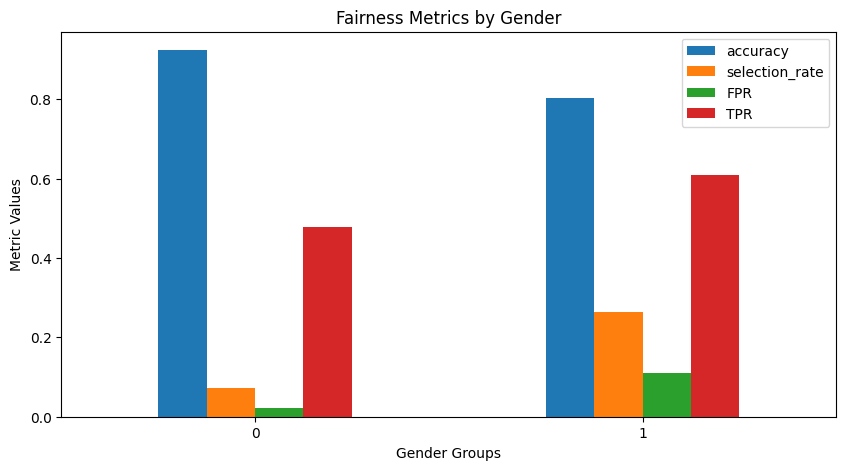

In [38]:
#Visualize fairness metrics using bar plots
mf.by_group.plot(kind='bar', figsize=(10,5))
#Add title and label of axis with xticks
plt.title("Fairness Metrics by Gender")
plt.xlabel("Gender Groups")
plt.ylabel("Metric Values")
plt.xticks(rotation=0)
plt.show()#display plot

# Explainability Analysis:

PermutationExplainer explainer: 9036it [03:01, 48.13it/s]                          
/tmp/ipykernel_20382/1929450212.py:13: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, 1], X_test_df)


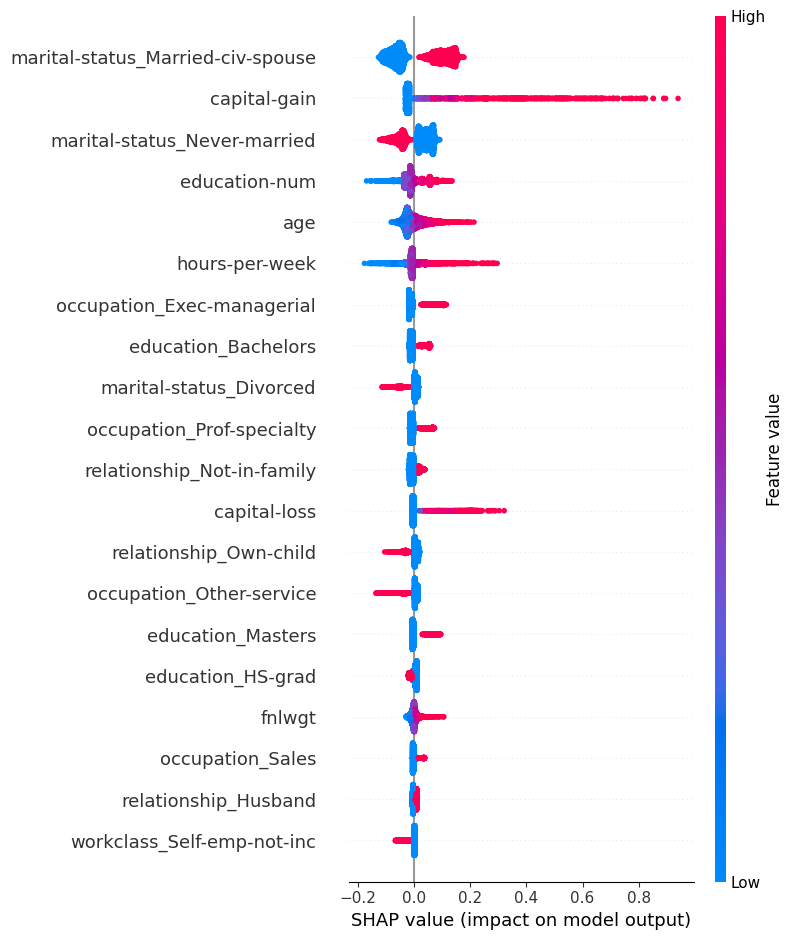

In [39]:
#Apply SHAP (SHapley Additive exPlanations)
# Create a SHAP explainer using the model's prediction function and X_test is used as background data to estimate feature contributions
explainer = shap.Explainer(model.predict_proba, X_test)


# Convert back to DataFrame with proper column names
X_test_df = pd.DataFrame(X_test, columns=X.columns)

# Compute SHAP values for the test dataset and SHAP values represent the contribution of each feature to the prediction
shap_values = explainer(X_test_df)

# Generate a summary plot (global explanation),shows overall feature importance and impact on predictions
shap.summary_plot(shap_values[:, :, 1], X_test_df)

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skle

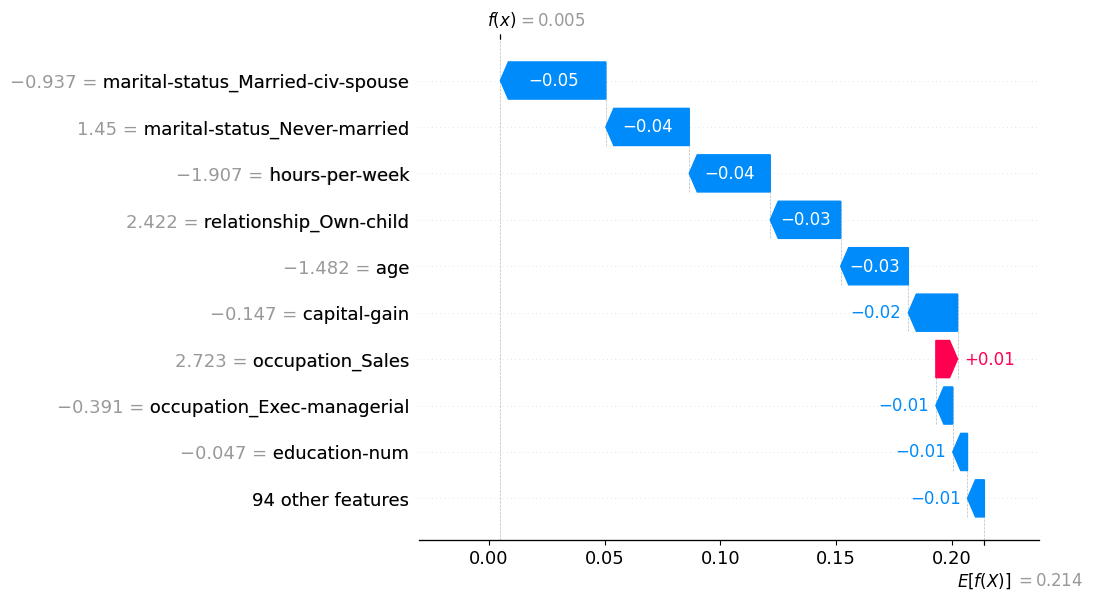

In [40]:
# Add LOCAL explanation with Waterfall Plot
# Select one instance
i = 0

# Recompute SHAP values properly (important!)
explainer = shap.Explainer(model.predict_proba, X_test_df)
shap_values = explainer(X_test_df)

# Waterfall plot for one instance (class 1 = >50K)
shap.plots.waterfall(shap_values[i, :, 1])

In [41]:
# LIME Analysis
# Create LIME explainer for tabular data
explainer = LimeTabularExplainer(
    training_data=np.array(X_train),   # Training data (must be numpy array)
    feature_names=X.columns,           # Feature names
    class_names=['<=50K', '>50K'],     # Target classes
    mode='classification'              # Classification task
)

# Select one test sample (convert to numpy array for compatibility)
sample = np.array(X_test[0])

# Explain prediction for one instance
exp = explainer.explain_instance(
    sample,                    # Single data point
    model.predict_proba       # Probability prediction function
)

# Show explanation in notebook
exp.show_in_notebook(show_table=True)